# Phase 4, Module 11: Dimensionality Reduction
In this notebook, we tackle the "Curse of Dimensionality." Sometimes, giving an AI too much information (100+ columns) can lead to confusion and poor performance.

We will cover:
1. **The PCA Concept**: Compressing data mathematically.
2. **Variance Check**: Seeing how much information we kept.
3. **2D Visualization**: Shrinking complex data so we can actually see it on a graph.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer

# Load a high-dimensional dataset (30 features!)
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)

print(f"Original dataset shape: {df.shape}")
print("We have 30 different columns of data. Let's simplify this.")

Original dataset shape: (569, 30)
We have 30 different columns of data. Let's simplify this.


## 1. Feature Scaling for PCA
**Crucial Note**: PCA is very sensitive to the scale of your data. We must use `StandardScaler` to ensure all columns (like 'radius' and 'smoothness') have equal mathematical weight before compression.[cite: 1]

In [2]:
# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print("Data scaled and ready for compression.")

Data scaled and ready for compression.


## 2. Applying PCA (Compressing 30 to 2)
We will now use PCA to compress our 30 columns into just 2 "Principal Components." We will then check the **Explained Variance Ratio** to see how much of the original "story" we managed to keep.[cite: 1]

In [3]:
# 1. Instantiate PCA to find the top 2 components
pca = PCA(n_components=2)

# 2. Fit and transform the scaled data
X_pca = pca.fit_transform(X_scaled)

# 3. Check how much information was kept
variance = pca.explained_variance_ratio_
print(f"Information kept in Component 1: {variance[0]*100:.2f}%")
print(f"Information kept in Component 2: {variance[1]*100:.2f}%")
print(f"Total information retained: {np.sum(variance)*100:.2f}%")

Information kept in Component 1: 44.27%
Information kept in Component 2: 18.97%
Total information retained: 63.24%


## 3. Visualizing 30 Dimensions in 2D
Now that we have compressed the data into X and Y coordinates (Component 1 and 2), we can finally plot it to see if the AI can distinguish between 'Malignant' and 'Benign' tumors visually.[cite: 1]

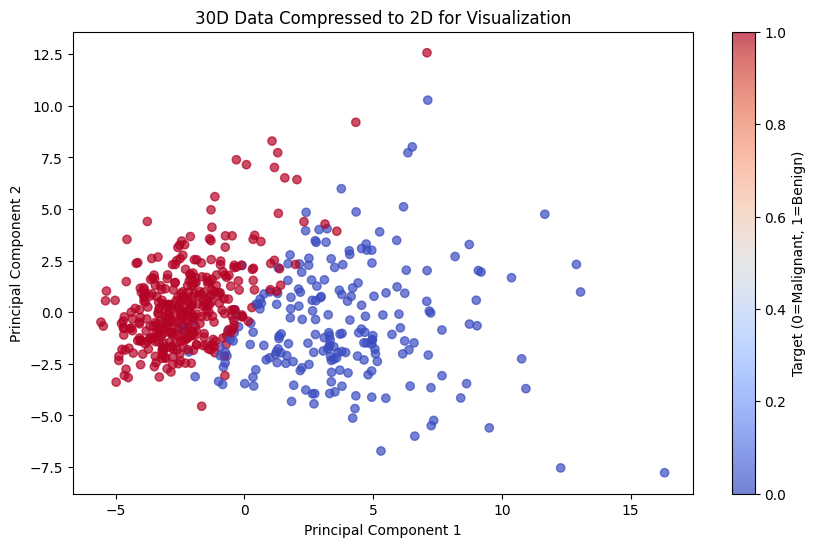

In [4]:
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=data.target, cmap='coolwarm', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('30D Data Compressed to 2D for Visualization')
plt.colorbar(label='Target (0=Malignant, 1=Benign)')
plt.show()

---
## 🎓 Student Task: The Data Compressor

In Task 8 of your curriculum, you are asked to handle a massive dataset.[cite: 1] 

Imagine you are working with IoT sensors at Islamia College that track 20 different variables (Temperature, Humidity, Air Quality, Vibration, etc.). This is too much for a simple dashboard.

**Your Goal**:
1. Apply **PCA** to the provided synthetic dataset `X_sensors`.[cite: 1]
2. Report the **Explained Variance Ratio** to prove how much information was kept.[cite: 1]
3. Create a 2D plot to see if the data points naturally group together.[cite: 1]

In [ ]:
# TASK: Compress the Sensor Data

# Generate 20-dimensional synthetic sensor data
from sklearn.datasets import make_blobs
X_sensors, _ = make_blobs(n_samples=200, n_features=20, centers=4, random_state=42)

# 1. Standardize the data
# YOUR CODE HERE

# 2. Apply PCA to reduce from 20 dimensions to 2
# my_pca = # YOUR CODE HERE
# X_compressed = # YOUR CODE HERE

# 3. Print the explained variance ratio
# print("Variance kept:", my_pca.explained_variance_ratio_)

# 4. Plot the results in 2D
# plt.scatter(X_compressed[:,0], X_compressed[:,1])
# plt.title("20D Sensor Data Compressed to 2D")
# plt.show()